# NLP + Finance: Exploratory Data Analysis

This notebook explores the Financial PhraseBank dataset — 
~4,800 financial news headlines annotated with sentiment labels.

**Goal:** Understand the data before building any models.
- What does the class distribution look like?
- Are there class imbalance issues?
- What do positive, negative, and neutral headlines look like?

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../data/raw/all-data.csv', 
                 encoding='latin-1', 
                 header=None,
                 names=['sentiment', 'headline'])

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Shape: (4846, 2)

First 5 rows:
  sentiment                                           headline
0   neutral  According to Gran , the company has no plans t...
1   neutral  Technopolis plans to develop in stages an area...
2  negative  The international electronic industry company ...
3  positive  With the new production plant the company woul...
4  positive  According to the company 's updated strategy f...


sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

Class percentages:
sentiment
neutral     59.4
positive    28.1
negative    12.5
Name: count, dtype: float64


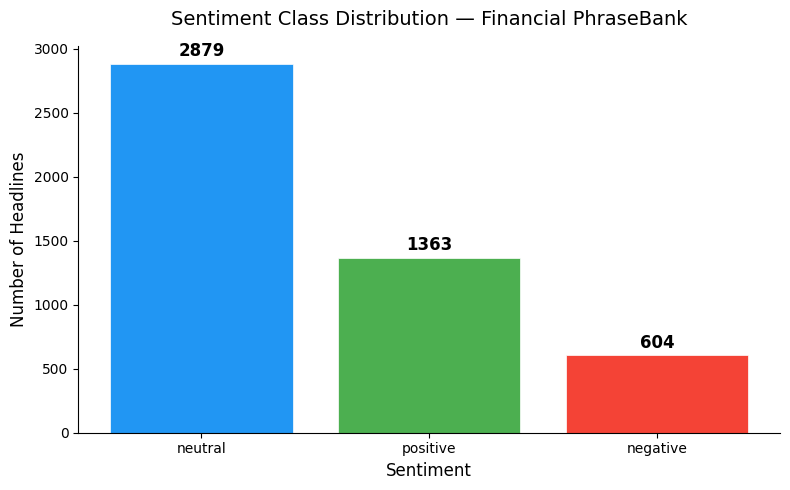

Chart saved to images/


In [2]:
import matplotlib.pyplot as plt

# Count each sentiment class
class_counts = df['sentiment'].value_counts()
print(class_counts)
print(f"\nClass percentages:")
print((class_counts / len(df) * 100).round(1))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2196F3', '#4CAF50', '#F44336']
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, 
            str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Sentiment Class Distribution — Financial PhraseBank', fontsize=14, pad=15)
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Headlines', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images/")

## What I notice about the class distribution

the dataset is really imbalanced - neutral takes up nearly 60% 
which i didn't expect. negative is only 12.5% which is a problem 
because that's actually the most important class for trading. if 
the model just guesses neutral every time it would still be "right" 
60% of the time which is why accuracy is basically useless here. 
switching to weighted F1 instead.

also, a model that misses negative headlines could literally 
generate a BUY signal right before bad news hits. that's the 
worst possible outcome for a trading system.

In [3]:
# Headline length analysis
df['headline_length'] = df['headline'].apply(lambda x: len(x.split()))

# Print average length per class
print("Average headline length by sentiment:")
print(df.groupby('sentiment')['headline_length'].mean().round(1))
print(f"\nOverall average: {df['headline_length'].mean().round(1)} words")

Average headline length by sentiment:
sentiment
negative    23.9
neutral     22.2
positive    24.7
Name: headline_length, dtype: float64

Overall average: 23.1 words


honestly, expected positive or negative headlines to be longer since they'd need more context to convey strong sentiment - but the averages are almost the same across all three classes (~22-25 words). Length alone won't be a useful feature for the model.

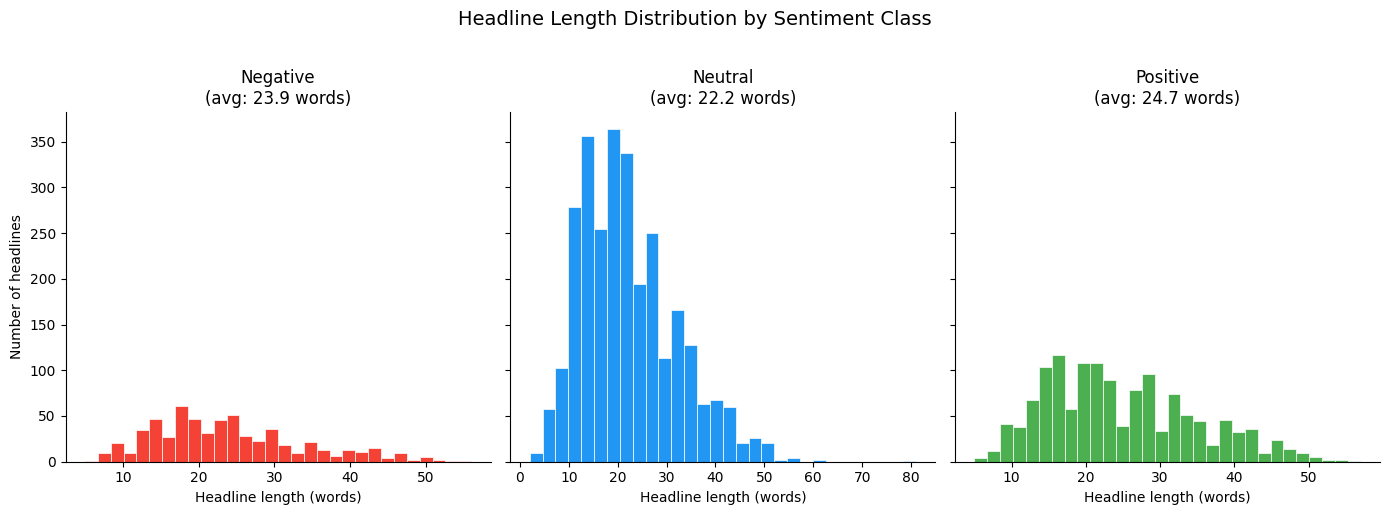

Chart saved.


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
colors = {'negative': '#F44336', 'neutral': '#2196F3', 'positive': '#4CAF50'}

for ax, sentiment in zip(axes, ['negative', 'neutral', 'positive']):
    subset = df[df['sentiment'] == sentiment]['headline_length']
    ax.hist(subset, bins=30, color=colors[sentiment], edgecolor='white', linewidth=0.5)
    ax.set_title(f'{sentiment.capitalize()}\n(avg: {subset.mean():.1f} words)', fontsize=12)
    ax.set_xlabel('Headline length (words)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Number of headlines')
fig.suptitle('Headline Length Distribution by Sentiment Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../images/headline_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

also noticed the neutral histogram has a sharper peak and longer tail than the other two - not sure what that means yet but it's different.

## Word Frequency Analysis

In [5]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re

nltk.download('stopwords', quiet=True)

standard_stops = set(stopwords.words('english'))

financial_stops = {
    'said', 'company', 'shares', 'quarter', 'year', 'million', 'billion',
    'percent', 'market', 'new', 'also', 'would', 'could', 'one', 'two',
    'first', 'last', 'mr', 'reuters', 'ft', 'eur', 'usd', 'inc', 'ltd',
    'corp', 'plc', 'group', 'says', 'report', 'reported', 'according'
}

stop_words = standard_stops | financial_stops

In [6]:
def get_top_words(df, sentiment_label, n=20):
    texts = df[df['sentiment'] == sentiment_label]['headline']
    
    words = []
    for headline in texts:
        tokens = re.findall(r'\b[a-z]+\b', headline.lower())
        words.extend([w for w in tokens if w not in stop_words and len(w) > 2])
    
    return Counter(words).most_common(n)

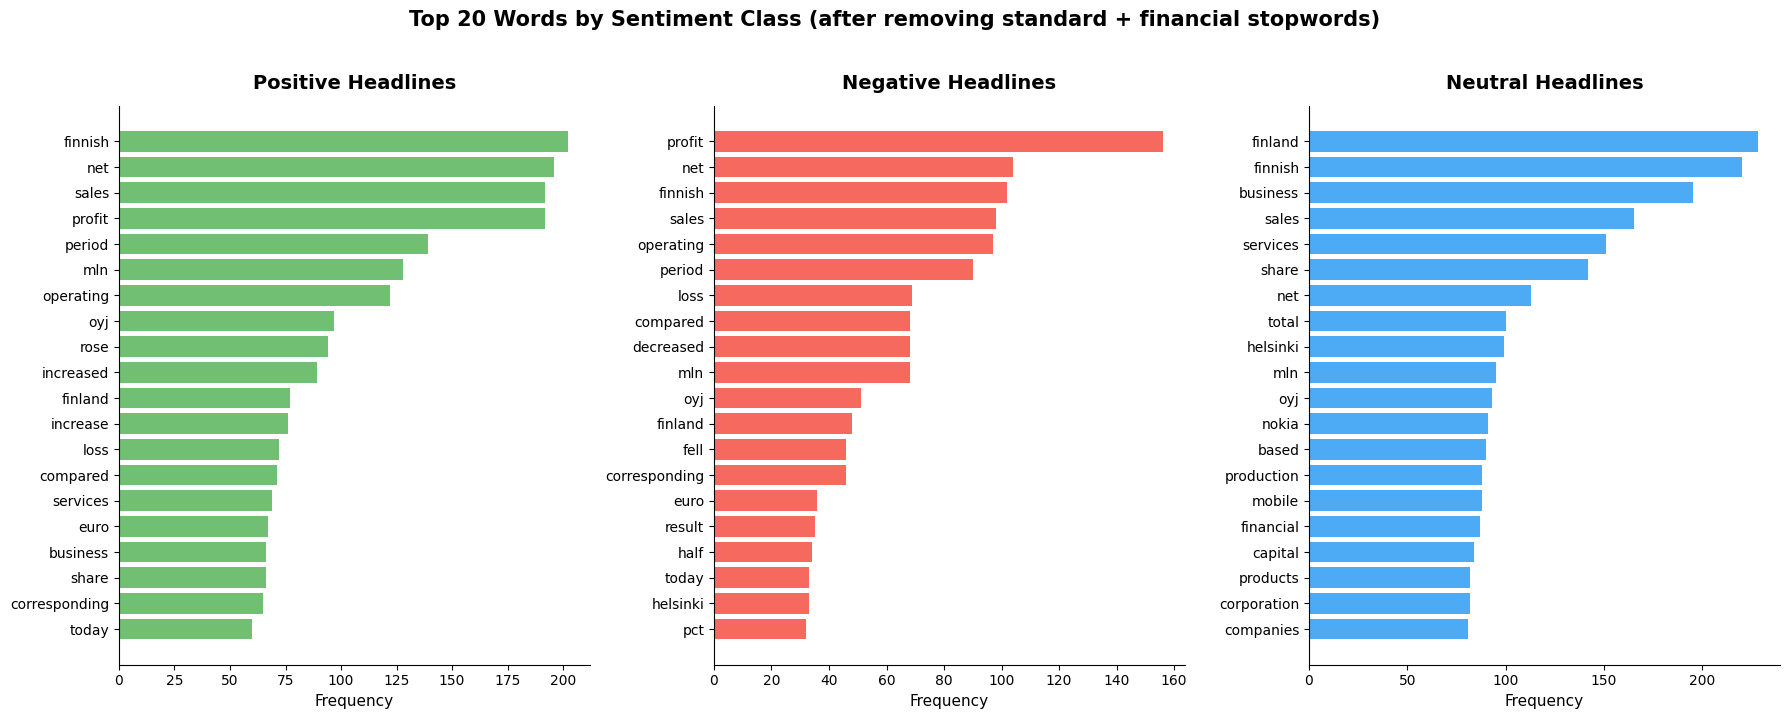

Chart saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

sentiments = ['positive', 'negative', 'neutral']
colors = ['#4CAF50', '#F44336', '#2196F3']
titles = ['Positive Headlines', 'Negative Headlines', 'Neutral Headlines']

for ax, sentiment, color, title in zip(axes, sentiments, colors, titles):
    top_words = get_top_words(df, sentiment, n=20)
    words, counts = zip(*top_words)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.8)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Frequency', fontsize=11)
    ax.tick_params(axis='y', labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Top 20 Words by Sentiment Class (after removing standard + financial stopwords)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/word_frequency_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

some words are clearly class-specific - "loss" and "decline" barely show up outside negative headlines, and "growth", "increase" lean heavily positive. but "profit" and "sales" appear across all three which makes sense, a headline can say profit grew or profit fell. so the vocabulary isn't perfectly separable. TF-IDF should still work but i'd expect it to struggle most on positive vs neutral since those two share the most overlap.
will be interesting to see if the model actually confirms this.

In [8]:
def get_top_word_set(df, sentiment_label, n=50):
    return set(w for w, _ in get_top_words(df, sentiment_label, n=50))

pos_words = get_top_word_set(df, 'positive')
neg_words = get_top_word_set(df, 'negative')
neu_words = get_top_word_set(df, 'neutral')

pos_only = pos_words - neg_words - neu_words
neg_only = neg_words - pos_words - neu_words
overlap = pos_words & neg_words

print("Words unique to POSITIVE:")
print(sorted(pos_only))

print("\nWords unique to NEGATIVE:")
print(sorted(neg_only))

print("\nWords in BOTH positive and negative:")
print(sorted(overlap))

Words unique to POSITIVE:
['agreement', 'grew', 'growth', 'increase', 'increased', 'months', 'nine', 'order', 'rose', 'russia', 'signed', 'supply']

Words unique to NEGATIVE:
['amounted', 'cut', 'decreased', 'due', 'earnings', 'employees', 'excluding', 'fell', 'half', 'items', 'january', 'lay', 'lower', 'negotiations', 'omx', 'pct', 'personnel', 'result', 'scanfil', 'september', 'staff', 'totaled', 'totalled']

Words in BOTH positive and negative:
['bank', 'compared', 'corresponding', 'earlier', 'euro', 'financial', 'finland', 'finnish', 'hel', 'helsinki', 'loss', 'maker', 'mln', 'net', 'operating', 'operations', 'oyj', 'per', 'period', 'profit', 'sales', 'second', 'share', 'third', 'today']


the overlap between positive and negative is mostly geographic and institutional terms - finland, helsinki, bank, euro. those aren't sentiment words, they're just common in this dataset because it's heavy on Nordic financial news. the actual sentiment vocabulary is pretty well separated. "grew", "growth", "rose" are almost exclusively positive. "fell", "cut", "decreased" are almost exclusively negative. this is more separable than i expected - TF-IDF might actually do okay here.

## This Week's Findings
the dataset has a significant class imbalance - neutral dominates at 59.4%, negative is only 12.5%. this rules out accuracy as a useful metric. switching to weighted F1.

headline length is almost identical across all three classes (~22-25 words). it won't be a useful feature - the model will need to work with the actual words, not structural properties.

the sentiment vocabulary is more separable than i expected. words like "fell", "cut", "decreased" are almost exclusive to negative. "grew", "growth", "rose" lean heavily positive. the overlap is mostly geographic terms (finland, helsinki) which are dataset-specific noise, not sentiment signals.

Next week: preprocessing and modeling. TF-IDF is the starting point. i'm most curious whether the positive vs neutral confusion i'm expecting actually shows up in the confusion matrix, or whether the model surprises me.